In [272]:
# Importing Libraries
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()
# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])


In [273]:
type(df['job_skills'][1])

str

In [274]:
def cleanup(data): 
    import ast 
    if pd.notna(data):
        return ast.literal_eval(data) 


In [275]:
df['job_skills']=df['job_skills'].apply(cleanup)


In [276]:
df=df.explode('job_skills')

In [277]:
df=df[df['job_title_short']=='Data Analyst']

In [278]:
df['month']=df['job_posted_date'].dt.month
top_skills=df['job_skills'].value_counts().head().index

In [279]:
df['job_posted_month']=pd.to_datetime(df['month'],format="%m").dt.month_name()

In [280]:
df_pivot=df.pivot_table(
    index='month',
    columns='job_skills',
    aggfunc='size'

)

df_pivot=df_pivot[top_skills]

In [281]:
df_pivot.reset_index(inplace=True)
df_pivot

job_skills,month,sql,excel,python,tableau,power bi
0,1,11336.0,8170.0,6606.0,5596.0,4285.0
1,2,7947.0,5772.0,4751.0,3936.0,3307.0
2,3,7868.0,5675.0,4741.0,4051.0,3176.0
3,4,7553.0,5496.0,4557.0,3776.0,3106.0
4,5,6617.0,4773.0,4070.0,3245.0,2695.0
5,6,7584.0,5724.0,4707.0,3812.0,3275.0
6,7,7687.0,5513.0,4831.0,3928.0,3350.0
7,8,8823.0,6482.0,5576.0,4533.0,3859.0
8,9,6829.0,4886.0,4229.0,3446.0,3118.0
9,10,7474.0,5217.0,4693.0,3709.0,3340.0


In [282]:
df_pivot['job_month']=pd.to_datetime(df_pivot['month'],format="%m").dt.month_name()

job_skills,month,sql,excel,python,tableau,power bi,job_month
0,1,11336.0,8170.0,6606.0,5596.0,4285.0,January
1,2,7947.0,5772.0,4751.0,3936.0,3307.0,February
2,3,7868.0,5675.0,4741.0,4051.0,3176.0,March
3,4,7553.0,5496.0,4557.0,3776.0,3106.0,April
4,5,6617.0,4773.0,4070.0,3245.0,2695.0,May
5,6,7584.0,5724.0,4707.0,3812.0,3275.0,June
6,7,7687.0,5513.0,4831.0,3928.0,3350.0,July
7,8,8823.0,6482.0,5576.0,4533.0,3859.0,August
8,9,6829.0,4886.0,4229.0,3446.0,3118.0,September
9,10,7474.0,5217.0,4693.0,3709.0,3340.0,October


In [285]:
df_pivot=df_pivot.set_index('job_month')
df_pivot
df_pivot=df_pivot.drop(columns='month')

Text(0.5, 1.0, 'skills trend over months')

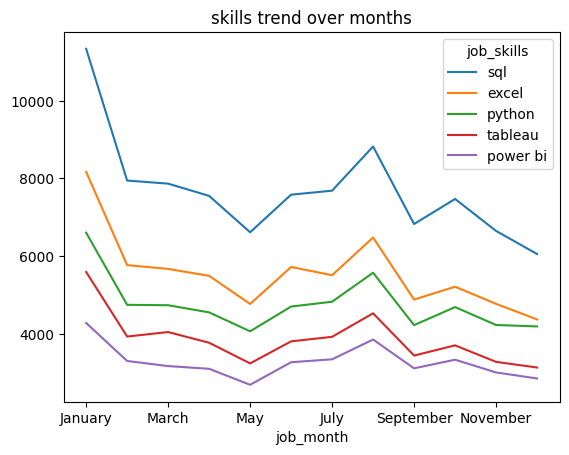

In [288]:

df_pivot.plot()
plt.title("skills trend over months")
